**Problem Statement:** <br>
Perform PCA in dimension reduction of numerical data

1. Pre-process the data through standardization.
2. Perform PCA to reduce dimension.
3. Construct the scree plot.
4. Data visualization in lower dimensional representation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
iris_dataset = load_iris()

features = iris_dataset.data
labels = iris_dataset.target
label_names = iris_dataset.target_names

iris_df = pd.DataFrame(features, columns=iris_dataset.feature_names)
iris_df['target_label'] = labels

print("Displaying the initial 5 rows of the Iris dataset:")
display(iris_df.head())

Displaying the initial 5 rows of the Iris dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target_label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
data_scaler = StandardScaler()
features_scaled = data_scaler.fit_transform(features)

print("Average of features after standardization (should be close to 0):")
print(np.mean(features_scaled, axis=0))

print("\nStandard deviation of features after standardization (should be 1):")
print(np.std(features_scaled, axis=0))

Average of features after standardization (should be close to 0):
[-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]

Standard deviation of features after standardization (should be 1):
[1. 1. 1. 1.]


In [ ]:
pca_full = PCA()
features_pca_full = pca_full.fit_transform(features_scaled)

print("Variance explained by each principal component:")
print(pca_full.explained_variance_ratio_)

Variance explained by each principal component:
[0.72962445 0.22850762 0.03668922 0.00517871]


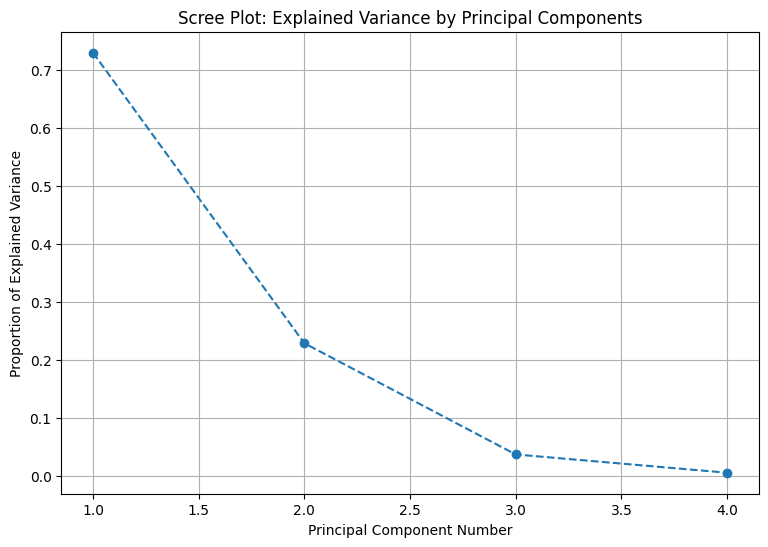

In [ ]:
plt.figure(figsize=(9, 6))
plt.plot(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    marker='o', linestyle='--'
)
plt.xlabel("Principal Component Number")
plt.ylabel("Proportion of Explained Variance")
plt.title("Scree Plot: Explained Variance by Principal Components")
plt.grid(True)
plt.show()

In [ ]:
pca_two_components = PCA(n_components=2)
features_pca_2d = pca_two_components.fit_transform(features_scaled)

print("Explained variance by the first two principal components:")
print(pca_two_components.explained_variance_ratio_)

Explained variance by the first two principal components:
[0.72962445 0.22850762]


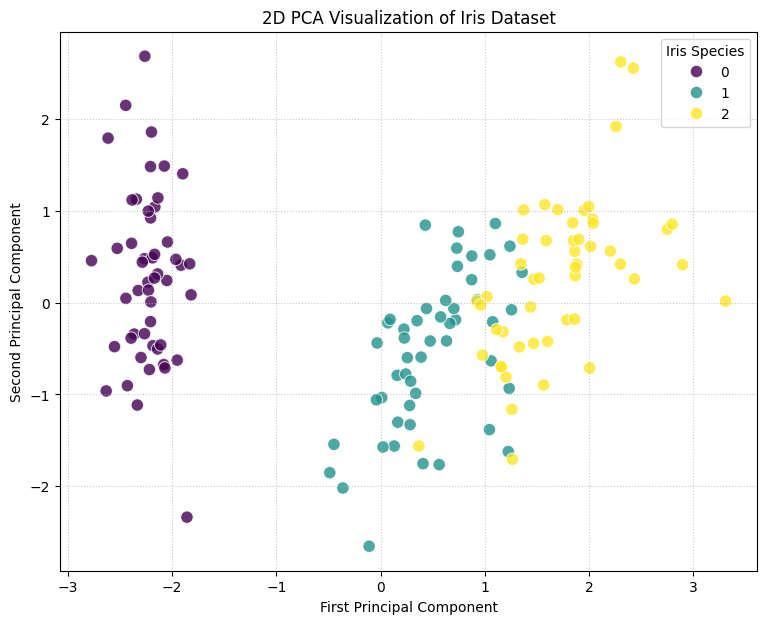

In [ ]:
pca_results_df = pd.DataFrame(features_pca_2d, columns=['Principal Component 1', 'Principal Component 2'])
pca_results_df['species_label'] = labels

plt.figure(figsize=(9, 7))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='species_label',
    data=pca_results_df,
    palette='viridis',
    s=80, alpha=0.8
)
plt.title("2D PCA Visualization of Iris Dataset")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.legend(title="Iris Species")
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

Conclusion:
1. PCA successfully reduced the original 4-dimensional data to 2 dimensions.
2. Most of the variance is captured by the first two principal components.
3. Visualization shows clear separation between Iris classes.